# **1. Data Cleaning & Preprocessing**



In [ ]:
#define paths for product and review datasets

PRODUCT_INFO = "product_info.csv"

REVIEWS0 = "reviews_0-250.csv"
REVIEWS1 = "reviews_250-500.csv"
REVIEWS2 = "reviews_500-750.csv"
REVIEWS3 = "reviews_750-1250.csv"
REVIEWS4 = "reviews_1250-end.csv"

In [ ]:
import pandas as pd

#loading the product info dataset
products = pd.read_csv(PRODUCT_INFO)


In [ ]:
!pip install nltk


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import nltk
import re
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
products.isnull().sum() #verify how many NaN values are in each column

product_id               0
product_name             0
brand_id                 0
brand_name               0
loves_count              0
rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1598
variation_desc        7244
ingredients            945
price_usd                0
value_price_usd       8043
sale_price_usd        8224
limited_edition          0
new                      0
online_only              0
out_of_stock             0
sephora_exclusive        0
highlights            2207
primary_category         0
secondary_category       8
tertiary_category      990
child_count              0
child_max_price       5740
child_min_price       5740
dtype: int64

handling duplicates

In [ ]:
products.duplicated().sum() #counting the nr of duplicates (identical rows)
products = products.drop_duplicates() # Removing duplicates

renaming columns for better understanding

In [ ]:
products = products.rename(columns={
    "loves_count": "popularity",
    "reviews": "review_count",
    "price_usd": "price",
    "brand_name": "brand",
    "primary_category": "category",
    "secondary_category": "subcategory",
    "child_count":"variants_count",
    "child_max_price":"var_max_price",
    "child_min_price":"var_min_price"


})
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         8494 non-null   object 
 1   product_name       8494 non-null   object 
 2   brand_id           8494 non-null   int64  
 3   brand              8494 non-null   object 
 4   popularity         8494 non-null   int64  
 5   rating             8216 non-null   float64
 6   review_count       8216 non-null   float64
 7   size               6863 non-null   object 
 8   variation_type     7050 non-null   object 
 9   variation_value    6896 non-null   object 
 10  variation_desc     1250 non-null   object 
 11  ingredients        7549 non-null   object 
 12  price              8494 non-null   float64
 13  value_price_usd    451 non-null    float64
 14  sale_price_usd     270 non-null    float64
 15  limited_edition    8494 non-null   int64  
 16  new                8494 

In [ ]:
products["category"] = products["category"].str.title() # standardizing the category names by converting them to title case


In [ ]:
review0=pd.read_csv(REVIEWS0)
review1=pd.read_csv(REVIEWS1)
review2=pd.read_csv(REVIEWS2)
review3=pd.read_csv(REVIEWS3)

#each file contains a part of the reviews from Sephora products .

C:\Users\DELL\AppData\Local\Temp\ipykernel_16696\3255544933.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  review0=pd.read_csv(REVIEWS0)
C:\Users\DELL\AppData\Local\Temp\ipykernel_16696\3255544933.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  review3=pd.read_csv(REVIEWS3)


merging the review files in a single dataframe

In [ ]:
reviews = pd.concat([
    review0,
    review1,
    review2,
    review3
], ignore_index=True)

# **2.Topic Modeling**

In [ ]:
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

selecting  a random sample of 50k reviews from the many many reviews in the dataframe

In [ ]:
sample_reviews = reviews.sample(
    n=50000,
    random_state=42
)

extracting  the reviews from the review_text column and converting it into a list

In [ ]:
documents = sample_reviews["review_text"].astype(str).tolist() #transforming them into a list because LDA and CountVectorizer work with lists , not dataframes

In [ ]:


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

using lemmatizer to reduce words to theur base form .
ex: loved,loving,loves ---> love


In [ ]:
lemmatizer = WordNetLemmatizer()  # used in order to reduce vocabulary size and help the topic modeling algorithm treat similar words as the same concept
stop_words = set(stopwords.words('english'))

In [ ]:
#we also removed the word "love" because eventhough it is meaningful for sentiment analysis , it does not help when talking about topic modeling.
# It appears in many reviews regardless of product type so it does not help distinguish between discussion topics

custom_stopwords = {
    "product",
    "products",
    "love",
    "like",
    "really",
    "get",
    "one",
    "would",
    "use",
    "using",
    "used",
    "try"
}


In [ ]:
#we map nltk part of speech tags to WordNet tags so that lemmatization can be performed more accurately

def nltk_pos_to_wordnet_pos(nltk_tag):
    if nltk_tag.startswith('J'): return wordnet.ADJ
    elif nltk_tag.startswith('V'): return wordnet.VERB
    elif nltk_tag.startswith('N'): return wordnet.NOUN
    elif nltk_tag.startswith('R'): return wordnet.ADV
    else: return None


#the preprocessing

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  #removing the link parts because they do not help the topic modeling

    text = text.translate(
        str.maketrans("", "", string.punctuation + string.digits)  # removing punctuation and digits
    )

    tokens = word_tokenize(text)  #transforming text into a list of tokens

    pos_tags = nltk.pos_tag(tokens) #mapping each word to a part of speech

    lemmas = [  #reducing the words to their base
        lemmatizer.lemmatize(
            word,
            nltk_pos_to_wordnet_pos(tag) or wordnet.NOUN
        )

        for word, tag in pos_tags

        if word.isalpha() #keeping only letters
        and len(word) > 2  #words that are longer than 2 letters
        and word not in stop_words  #and removing the stopwords
        and word not in custom_stopwords #and the custom stopwords that we set
    ]

    return " ".join(lemmas) #then transforming the list of tokens back into text

In [ ]:

preprocessed_documents = [preprocess_text(doc) for doc in documents]


Preprocessing documents...
Preprocessing complete.


In [ ]:
!pip install scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


we transformed the preprocessed reviews into a document term matrix (dtm) using CountVectorizer. We kept terms appearing in at least 20 reviews, removed overly common terms , and included both single words and two-words expressions. This representation was then used as input for the LDA topic modeling algorithm

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer #transforming the text into numbers

vectorizer = CountVectorizer(  #removes the words that appear in more than 85% of the reviews. If they appear in so many , then basically they don't help to differentiate topics
    max_df=0.85,
    min_df=20,
    ngram_range=(1,2)
)

dtm = vectorizer.fit_transform(  #transforms the processed reviews into a matrix (for LDA)
    preprocessed_documents
)

feature_names = vectorizer.get_feature_names_out() #extracts the words and bigrams from the vocabulary

Latent Dirichlet Allocation

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
#finding topics that appear frequently in the reviews
lda_model = LatentDirichletAllocation(
    n_components=5,   #5 topics ( 5 topics produceed meaningful and distinct themes without creating excessive overlap)
    random_state=42,
    learning_method="online",
    max_iter=20,
    n_jobs=-1
)

lda_model.fit(dtm) #aici se antreneaza efectiv modelul



,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'online'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,20
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


The function recieves as parameters : the model (lda) , feature names (the vocabulary )  , and n-top-words (how many wwords to display for each topic)

In [ ]:
def print_top_words(model, feature_names, n_top_words):

    for topic_idx, topic in enumerate(model.components_): #in model.components are the topics stored

        top_words = [
            feature_names[i] #we transform the index into the word
            for i in topic.argsort()[:-n_top_words - 1:-1]  # we sort the words based on importance( the weight)
        ]

        print(f"\nTopic #{topic_idx + 1}")
        print(" | ".join(top_words)) #displaying the most important words associated with each discovered topic

In [ ]:
print_top_words(
    lda_model,
    feature_names,
    15
)


Topic #1
skin | acne | lip | week | see | help | day | difference | line | work | notice | start | result | time | mask

Topic #2
eye | cream | serum | night | long | morning | apply | little | go | look | way | routine | day | notice | eye cream

Topic #3
skin | feel | make | dry | moisturizer | oily | look | hydrate | great | soft | skin feel | leave | sensitive | recommend | make skin

Topic #4
smell | good | buy | face | get | think | sample | price | work | size | much | say | try | bottle | receive

Topic #5
face | makeup | cleanser | skin | leave | clean | wash | dry | remove | gentle | best | cleanse | oil | sunscreen | mask


Analyzing how many reviews each topic has

In [ ]:
topic_distribution = lda_model.transform(dtm) #assigns a topic probability distribution to each review. Each review receives a probability score for every discovered topic

dominant_topic = topic_distribution.argmax(axis=1) #chooses the topic with the biggest probability

In [ ]:
import pandas as pd

topic_counts = pd.Series(dominant_topic).value_counts().sort_index()

print(topic_counts)

0    10945
1     6119
2    17421
3     9632
4     5883
Name: count, dtype: int64


After finding 5 topics and their most important words with LDA, we chose for each one a title , so that they are easier to understand

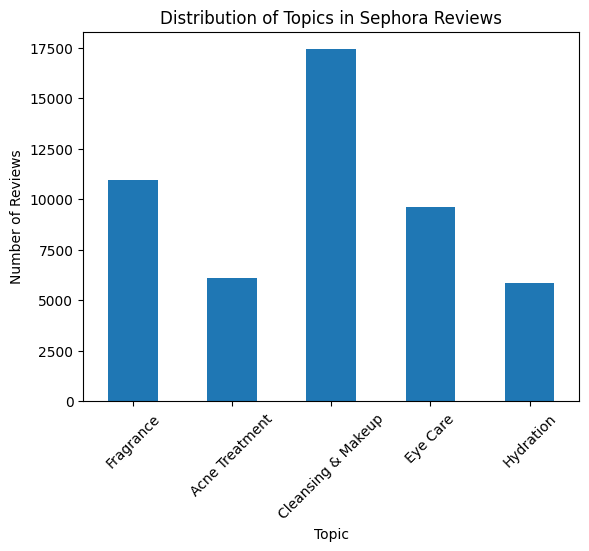

In [ ]:
import matplotlib.pyplot as plt
topic_labels = {
    0: "Fragrance",
    1: "Acne Treatment",
    2: "Cleansing & Makeup",
    3: "Eye Care",
    4: "Hydration"
}

topic_counts.index = [
    topic_labels[i]
    for i in topic_counts.index
]

topic_counts.plot(kind="bar")

plt.title("Distribution of Topics in Sephora Reviews")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.show()

#here we analyze discussions and their frequency

# **3.Sentiment Analysis**

Valence Aware Dictionary and Sentiment Reasoner.
It receives a text and computes a sentiment score

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()  #initializing the vadersentiment analyzer


calculating the sentiment for each review

In [ ]:
sample_reviews["sentiment"] = (
    sample_reviews["review_text"]
    .astype(str)
    .apply(
        lambda x:
        sia.polarity_scores(x)["compound"] #scorul final
    )
)

In [ ]:
sample_reviews["sentiment"].describe() #computes descriptive statistics for the sentiment scores

count    50000.000000
mean         0.672689
std          0.418075
min         -0.992100
25%          0.611400
50%          0.851400
75%          0.937300
max          0.998600
Name: sentiment, dtype: float64

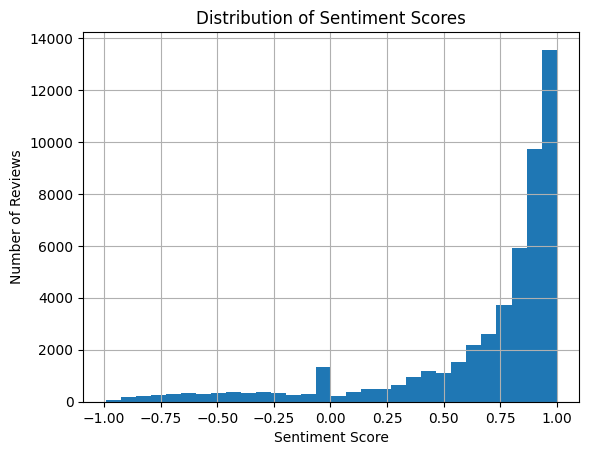

In [ ]:
import matplotlib.pyplot as plt

sample_reviews["sentiment"].hist(
    bins=30
)

plt.title(
    "Distribution of Sentiment Scores"
)

plt.xlabel(
    "Sentiment Score" #from -1 to 1
)

plt.ylabel(
    "Number of Reviews"
)

plt.show()

#we can observe that most reviews are positive

In [ ]:
def sentiment_label(score):  #here we map the scores to their respective category ( low scores => negative review)

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    return "Neutral"

In [ ]:
sample_reviews["sentiment_label"] = (
    sample_reviews["sentiment"]
    .apply(sentiment_label)
)

In [ ]:
sample_reviews[
    "sentiment_label"
].value_counts()

sentiment_label
Positive    44543
Negative     4052
Neutral      1405
Name: count, dtype: int64

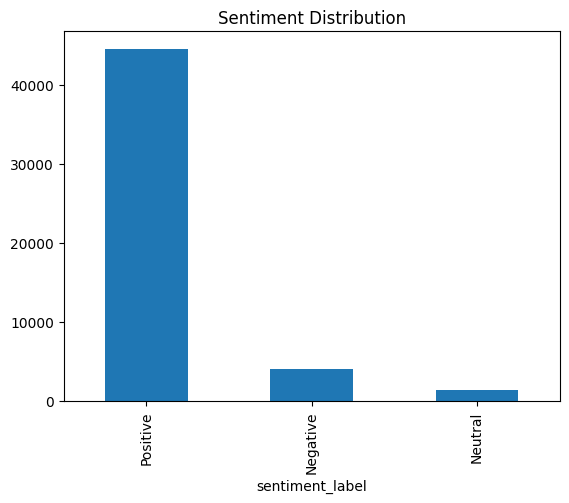

In [ ]:
sample_reviews[
    "sentiment_label"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Sentiment Distribution"
)

plt.show()

#basically the same as the previous histogram , but easier to understand

Top brands with the best reviews VS Top brands with the worst reviews

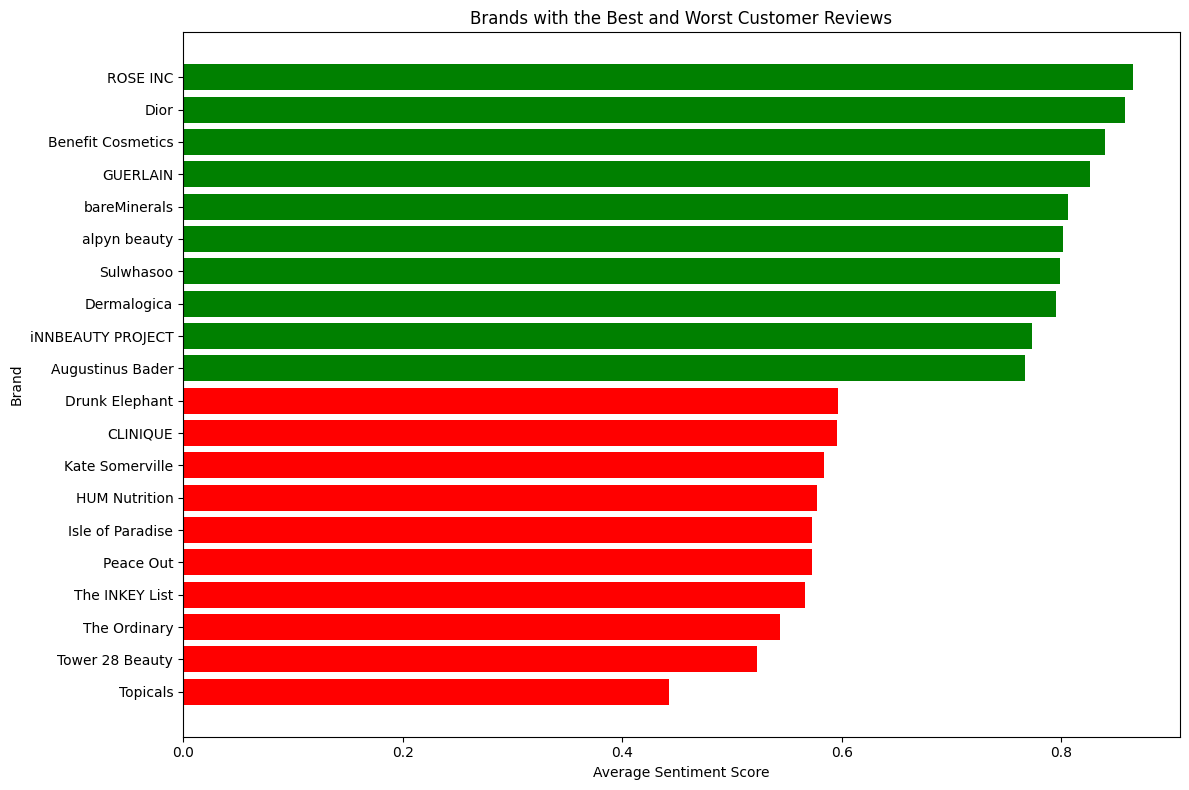

In [ ]:

#we merge the reviews with the products because in the sample_reviews we do not have the brands. so we merge them by product_id
reviews_enriched = sample_reviews.merge(
    products[["product_id","brand"]],
    on="product_id"
)


#grouping the reviews by brand
brand_stats = (
    reviews_enriched
    .groupby("brand")
    .agg(
        avg_sentiment=("sentiment","mean"),
        review_count=("sentiment","count")
    )
)

#we eliminate the brands with too little reviews

brand_stats = brand_stats[
    brand_stats["review_count"] >= 50
]

#top 10 best brands
best_brands = brand_stats.nlargest(
    10,
    "avg_sentiment"
)

#top 10 worst brands
worst_brands = brand_stats.nsmallest(
    10,
    "avg_sentiment"
)



#then we combine the list with the best brands and the worst brands
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.concat([
    best_brands.assign(group="Best"),
    worst_brands.assign(group="Worst")
])

comparison = comparison.sort_values("avg_sentiment")

plt.figure(figsize=(12,8))

colors = [ #the best brands are green and the worst brands are red
    "green" if g == "Best" else "red"
    for g in comparison["group"]
]

plt.barh(
    comparison.index,
    comparison["avg_sentiment"],
    color=colors
)

plt.title("Brands with the Best and Worst Customer Reviews")
plt.xlabel("Average Sentiment Score")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()


Price vs Popularity: Do expensive beauty products become more popular?

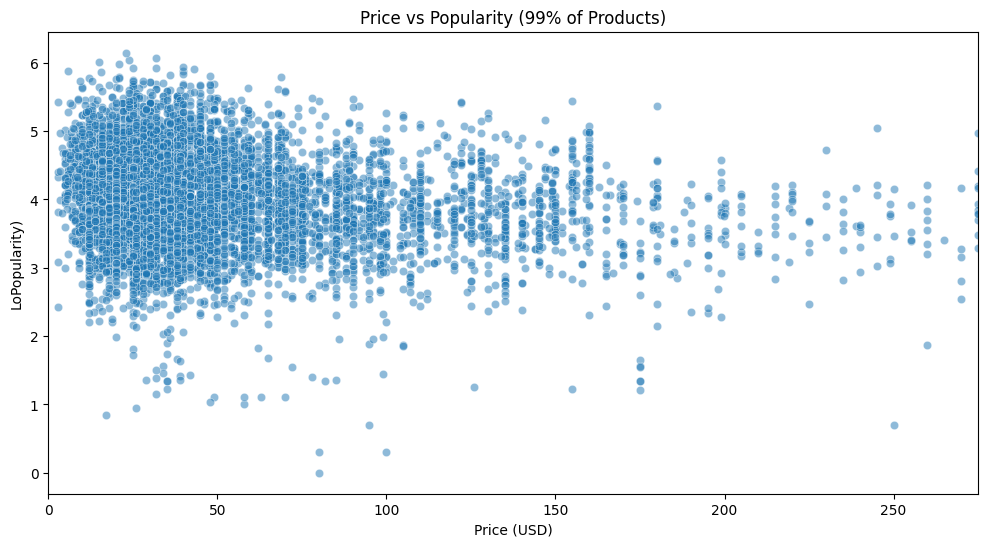

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plot_data = products.copy() # we cpoy the dataset so that we don't change the original one

plot_data = plot_data[ #eliminate the products with invalid price ore popularity values
    (plot_data["price"] > 0)
    & (plot_data["popularity"] > 0)
]

price_limit = plot_data["price"].quantile(0.99) #compute the 99th percentile to reduce the effect of extreme price outliars

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=plot_data,
    x="price",
    y=np.log10(plot_data["popularity"]),
    alpha=0.5
)

plt.xlim(0, price_limit)

plt.title(
    "Price vs Popularity (99% of Products)"
)

plt.xlabel("Price (USD)")
plt.ylabel("LoPopularity)")

plt.show()

We investigated whether more expensive products tend to become more popular. The correlation between price and popularity was -0.09 suggesting a weak/moderate relationship. So expensive products are not necessarily more popular than affordable ones

# **4.Feature Importance for Virality**

Model Accuracy: 0.868

Feature Importance:
             feature  importance
1       review_count    0.468910
3      avg_sentiment    0.177290
2              price    0.151278
0             rating    0.149597
6  sephora_exclusive    0.025280
4        online_only    0.021986
5    limited_edition    0.005658


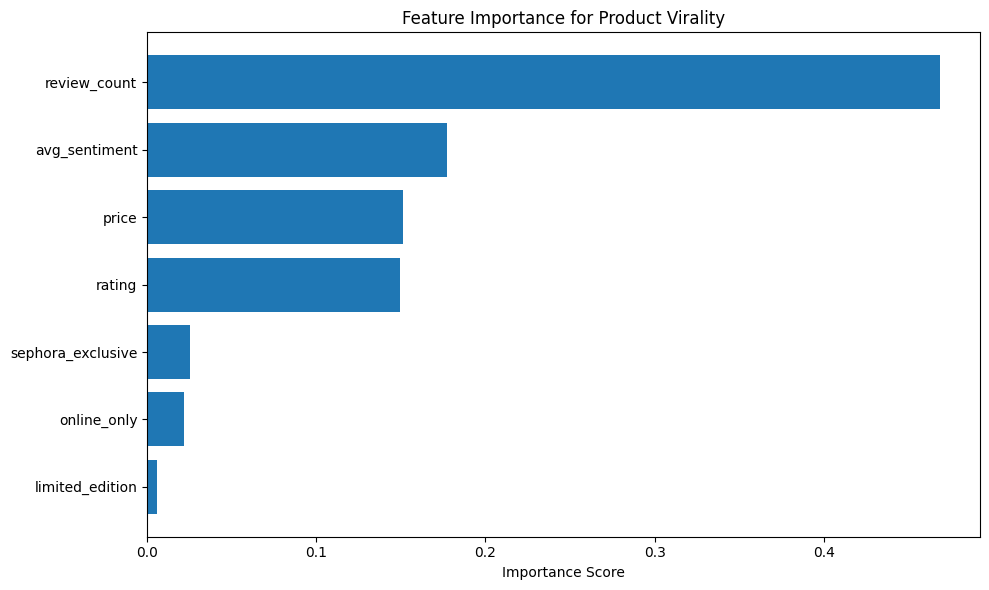

In [ ]:

#This transforms the problem into a binary classification task.
viral_threshold = products["popularity"].quantile(0.9)

products["viral"] = (
    products["popularity"] >= viral_threshold
).astype(int)


# Average sentiment per product
product_sentiment = (
    reviews_enriched
    .groupby("product_id")
    .agg(
        avg_sentiment=("sentiment", "mean")
    )
    .reset_index()
) # one sentiment score per product.


# Merge sentiment with products
products_ml = products.merge(
    product_sentiment,
    on="product_id",
    how="left"
)


features = [
    "rating",
    "review_count",
    "price",
    "avg_sentiment",
    "online_only",
    "limited_edition",
    "sephora_exclusive"
]

# Remove missing values
data_ml = products_ml[
    features + ["viral"]
].dropna()




X = data_ml[features]

y = data_ml["viral"]


#Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Train Random Forest


from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)


# Evaluate Model


from sklearn.metrics import accuracy_score

predictions = rf.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(f"Model Accuracy: {accuracy:.3f}")

# 10. Feature Importance


import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)


# 11. Plot Feature Importance


import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.title(
    "Feature Importance for Product Virality"
)

plt.xlabel(
    "Importance Score"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# 5.Data Visualization

Rating vs Popularity

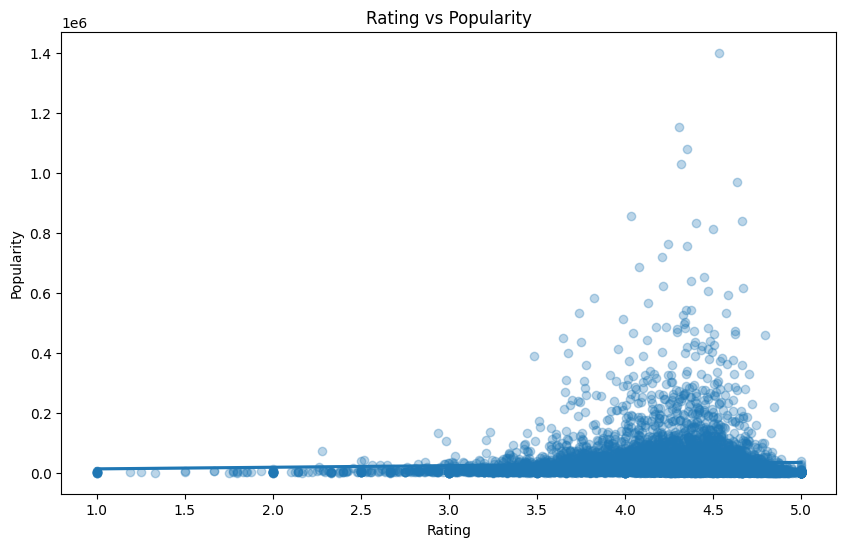

              rating  popularity
rating      1.000000    0.041797
popularity  0.041797    1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

#relationship between product ratings and popularity
sns.regplot(
    data=products,
    x="rating",
    y="popularity",
    scatter_kws={"alpha":0.3}
)

plt.title("Rating vs Popularity")
plt.xlabel("Rating")
plt.ylabel("Popularity")

plt.show()

#we calculated the Pearson correlation coefficient between rating and popularity
print(
    products[["rating","popularity"]]
    .corr()
)

Correlation Heatmap

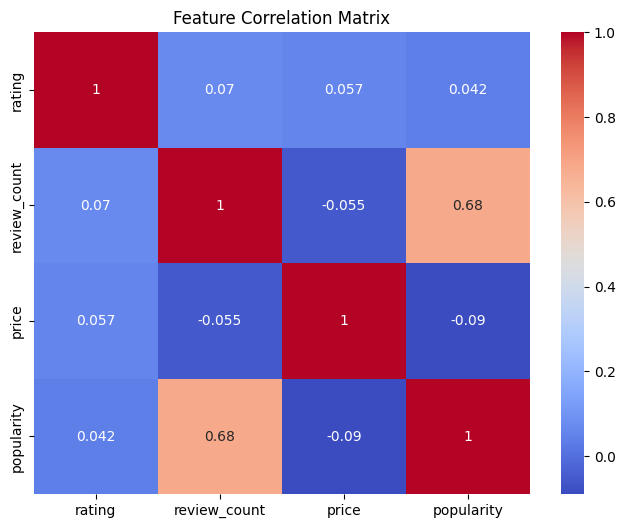

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#We selected the main numerical variables that could potentially influence popularity.
corr_features = [
    "rating",
    "review_count",
    "price",
    "popularity"
]

corr_matrix = products[
    corr_features
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

# **6.Supervized model**

In [ ]:
#we transformed the problem into a supervised classification task
viral = 1
non_viral = 0
viral_threshold = products["popularity"].quantile(0.9)

products["viral"] = (
    products["popularity"] >= viral_threshold
).astype(int)

products["viral"].value_counts()


viral
0    7644
1     850
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

data_ml = products_ml[
    features + ["viral"]
].dropna()

X = data_ml[features]

y = data_ml["viral"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
#This evaluates model performance based on precision , recall , f1-score and accuracy
print(
    classification_report(
        y_test,
        predictions
    )
)
cm = confusion_matrix(
    y_test,
    predictions
)

(996, 7)
(250, 7)
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       204
           1       0.72      0.46      0.56        46

    accuracy                           0.87       250
   macro avg       0.81      0.71      0.74       250
weighted avg       0.86      0.87      0.86       250



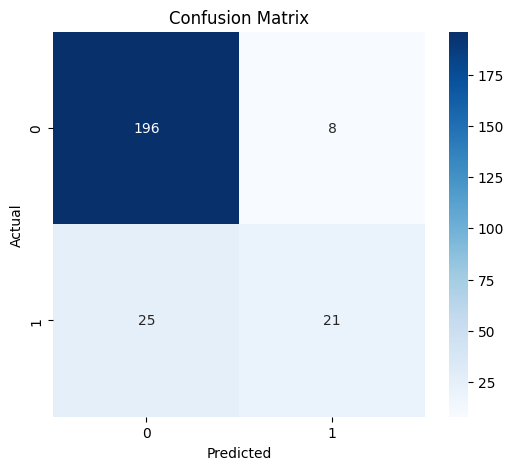

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#The confusion matrix shows exactly where the model was correct and where it made mistakes.
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **7.Information retrieval**

In [ ]:
#First, we transformed each product into a text document because Information Retrieval algorithms work with text documents.
products["document"] = (
    products["product_name"].fillna("").astype(str)
    + " "
    + products["brand"].fillna("").astype(str)
    + " "
    + products["category"].fillna("").astype(str)
    + " "
    + products["subcategory"].fillna("").astype(str)
    + " "
    + products["highlights"].fillna("").astype(str)
)
print(products["document"].iloc[0])

Fragrance Discovery Set 19-69 Fragrance Value & Gift Sets ['Unisex/ Genderless Scent', 'Warm &Spicy Scent', 'Woody & Earthy Scent', 'Fresh Scent']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#Convert Text into Numerical Vectors
vectorizer = TfidfVectorizer(
    stop_words="english"
)

#The vectorizer learns the vocabulary from all product documents.
tfidf_matrix = vectorizer.fit_transform(
    products["document"]
)

print(tfidf_matrix.shape)


(8494, 4416)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
#Creates a custom search engine.
def search_products(query, top_n=5):

    query_vector = vectorizer.transform([query]) # now both products and query exists in the same vector space

    #Measures how similar the query is to every product.
    similarity_scores = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    #Sorts products by similarity score.
    top_indices = similarity_scores.argsort()[-top_n:][::-1]

    results = products.iloc[top_indices][
        [
            "product_name",
            "brand",
            "category",
            "rating",
            "price"
        ]
    ].copy()

    results["similarity_score"] = (
        similarity_scores[top_indices]
    )

    return results

examples:

In [ ]:
search_products(
    "hydrating moisturizer dry skin"
)

,product_name,brand,category,rating,price,similarity_score
4434,Cream Skin Toner & Moisturizer,LANEIGE,Skincare,4.4481,33.0,0.498726
1652,Hydrating Oil-Free Gel Moisturizer,Community Sixty-Six,Skincare,4.1245,25.0,0.492045
2783,Vitamin C Glow Moisturizer,fresh,Skincare,4.2411,48.0,0.452017
7945,Protect + Plump Firming & Hydrating Face Moist...,TULA Skincare,Skincare,3.9630,64.0,0.398602
3544,Green Tea Hyaluronic Acid Hydrating Moisturizer,innisfree,Skincare,4.7299,29.0,0.397652


In [ ]:
search_products(
    "acne treatment oily skin"
)

,product_name,brand,category,rating,price
6780,Acne Treatment Gel,SEPHORA COLLECTION,Skincare,5.0000,20.0
3906,EradiKate Acne Treatment,Kate Somerville,Skincare,4.2243,28.0
2703,ESPADA Blue Light Acne Treatment,FOREO,Skincare,3.8873,159.0
3912,EradiKate Daily Cleanser Acne Treatment,Kate Somerville,Skincare,4.2392,44.0
5189,Deep Relief Acne Treatment with Salicylic Acid,Murad,Skincare,4.7074,45.0


In [ ]:
search_products(
    "fragrance woody scent"
)

,product_name,brand,category,rating,price
0,Fragrance Discovery Set,19-69,Fragrance,3.6364,35.0
7782,Santal Blush,TOM FORD,Fragrance,4.4286,180.0
3041,Bamboo Eau de Parfum,Gucci,Fragrance,4.4101,87.0
3954,Discovery Sampler Set,KAYALI,Fragrance,3.6066,25.0
7762,Oud Wood,TOM FORD,Fragrance,4.4396,295.0


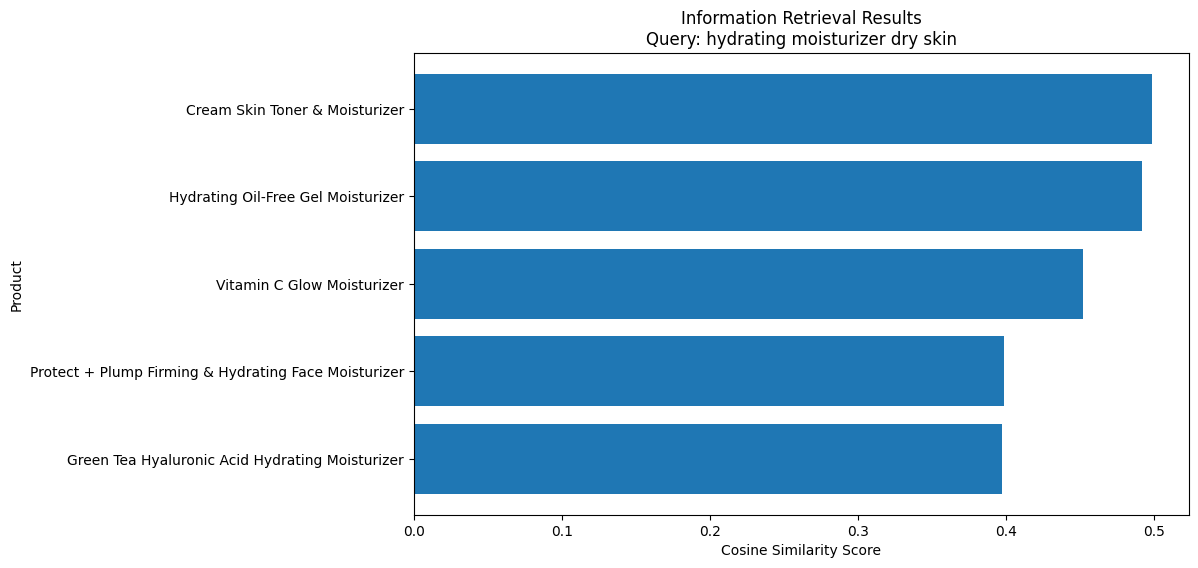

In [ ]:
results = search_products(
    "hydrating moisturizer dry skin"
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    results["product_name"],
    results["similarity_score"]
)

plt.title(
    "Information Retrieval Results\nQuery: hydrating moisturizer dry skin"
)

plt.xlabel(
    "Cosine Similarity Score"
)

plt.ylabel(
    "Product"
)

plt.gca().invert_yaxis()

plt.show()